In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pyparsing import col

df=pd.read_csv("netflix_titles.csv")

df.tail()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Movies vs Tv Shows

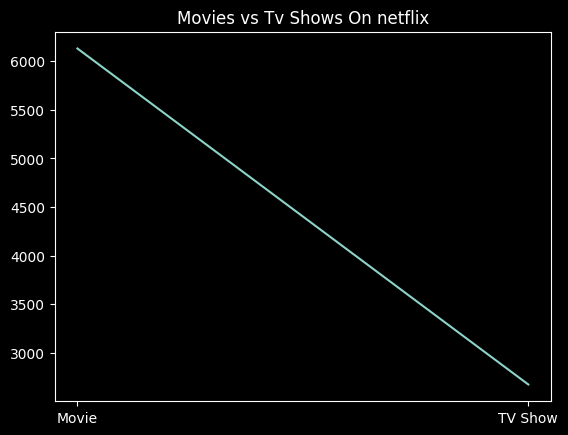

In [8]:
type_count=df["type"].value_counts()
plt.plot(type_count.index,type_count.values)
plt.title("Movies vs Tv Shows On netflix")
plt.show()


Content Added Over Years

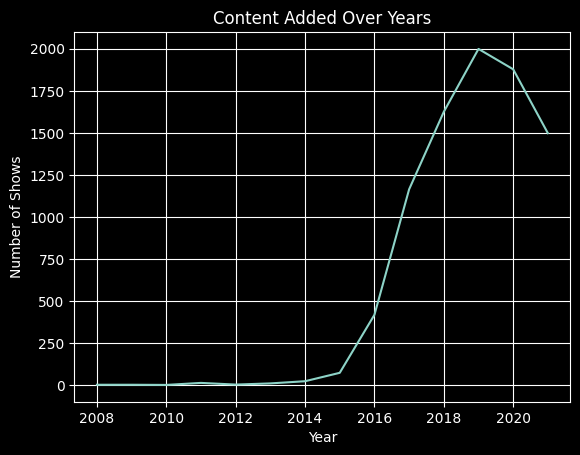

In [12]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")
df["year_added"]=df["date_added"].dt.year

year_data=df["year_added"].value_counts().sort_index()
plt.plot(year_data.index,year_data.values)

plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.grid(True)

plt.show()

Top 10 Countries Producing Content

Index([2818, 972, 419, 245, 199, 181, 145, 124, 110, 106], dtype='int64', name='count')


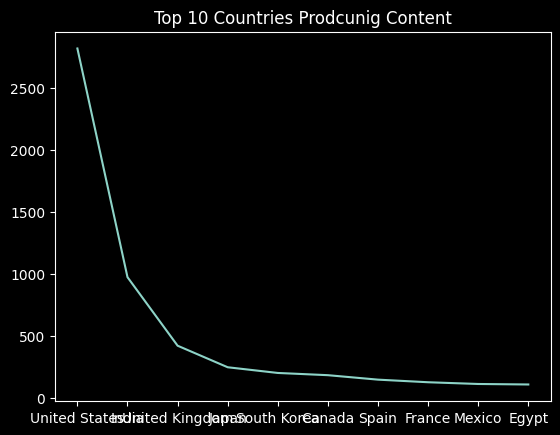

In [17]:
top_countries=df["country"].value_counts().head(10)
plt.plot(top_countries.index,top_countries.values)
plt.title("Top 10 Countries Prodcunig Content")
plt.show()


In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


Top 10 Genres

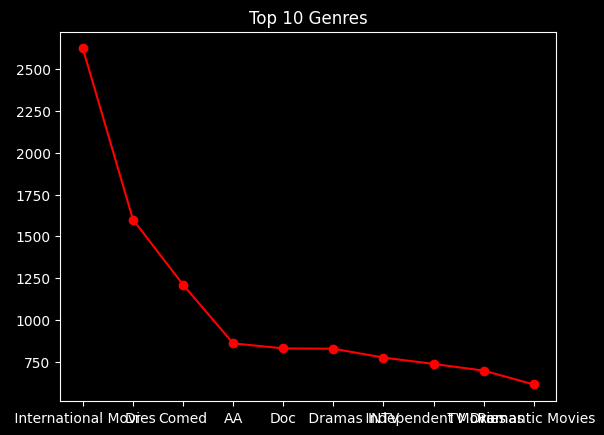

In [27]:
genre_data=df["listed_in"].str.split(",").explode()
Genre=genre_data.value_counts().head(10)
Genre.rename(index={"International Movies":"INT","Dramas":"Dr","Comedies":"Comed","Action & Adventure":"AA","Documentaries":"Doc","Dramas":"Dr","International TV Shows":"INTV","Independent Movies":"INM"},inplace=True)
plt.plot(Genre.index,Genre.values,color="red",marker="o")
plt.title("Top 10 Genres")
plt.show()

<Axes: xlabel='year_added'>

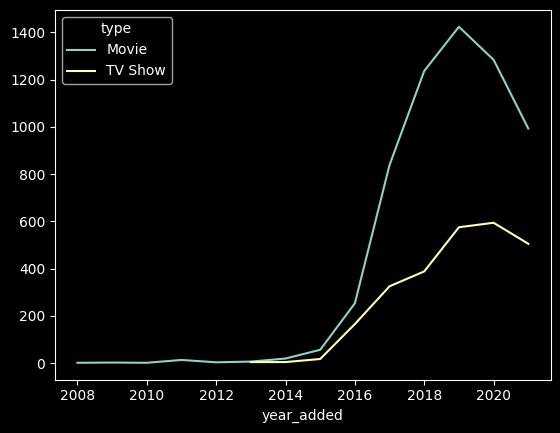

In [31]:
type_year=df.groupby(["year_added","type"]).size().unstack()
type_year.plot()